In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("heart_disease_uci.csv")
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
df=df.drop_duplicates()

In [6]:
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [7]:
mean_columns=['trestbps','chol','thalch','oldpeak','ca']
mode_columns=['fbs','restecg','exang','slope','thal']
for col in mean_columns:
    df[col].fillna(df[col].mean(),inplace=True)
for col in mode_columns:
    df[col].fillna(df[col].mode()[0],inplace=True)

C:\Users\mange\AppData\Local\Temp\ipykernel_6664\417277755.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace=True)
C:\Users\mange\AppData\Local\Temp\ipykernel_6664\417277755.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

In [8]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [9]:
df1=df[['age','cp','chol','thalch']]
df2=df[['exang','slope','thal']]

In [10]:
merged_df=pd.concat([df1,df2],axis=1)

In [11]:
merged_df

,age,cp,chol,thalch,exang,slope,thal
0,63,typical angina,233.0,150.000000,False,downsloping,fixed defect
1,67,asymptomatic,286.0,108.000000,True,flat,normal
2,67,asymptomatic,229.0,129.000000,True,flat,reversable defect
3,37,non-anginal,250.0,187.000000,False,downsloping,normal
4,41,atypical angina,204.0,172.000000,False,upsloping,normal
...,...,...,...,...,...,...,...
915,54,asymptomatic,333.0,154.000000,False,flat,normal
916,62,typical angina,139.0,137.545665,False,flat,normal
917,55,asymptomatic,223.0,100.000000,False,flat,fixed defect
918,58,asymptomatic,385.0,137.545665,False,flat,normal


In [13]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [14]:
categorical_cols = ['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal']
label_encoder=LabelEncoder()
for col in categorical_cols:
    df[col]=label_encoder.fit_transform(df[col])

In [15]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,True,0,150.0,False,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,False,0,108.0,True,1.5,1,3.0,1,2
2,3,67,1,0,0,120.0,229.0,False,0,129.0,True,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,False,1,187.0,False,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,False,0,172.0,False,1.4,2,0.0,1,0


In [16]:
numeric_cols=['age','trestbps','chol','thalch','oldpeak','ca']
scaler=StandardScaler()
df[numeric_cols]=scaler.fit_transform(df[numeric_cols])

In [17]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,1.007386,1,0,3,0.698041,0.311021,True,0,0.495698,False,1.349421,0,-1.249371,0,0
1,2,1.432034,1,0,0,1.511761,0.797713,False,0,-1.175955,True,0.589832,1,4.292099,1,2
2,3,1.432034,1,0,0,-0.658158,0.274289,False,0,-0.340128,True,1.634267,1,2.444942,2,1
3,4,-1.752828,1,0,2,-0.115679,0.467130,False,1,1.968345,False,2.488805,0,-1.249371,1,0
4,5,-1.328180,0,0,1,-0.115679,0.044717,False,0,1.371326,False,0.494884,2,-1.249371,1,0


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
def remove_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    threshold = 2.5 * IQR
    column = column[(column >= Q1 - threshold) & (column <= Q3 + threshold)]
    return column.fillna(column.median())


In [20]:
for col in numeric_cols:
    df[col]=remove_outliers(df[col])

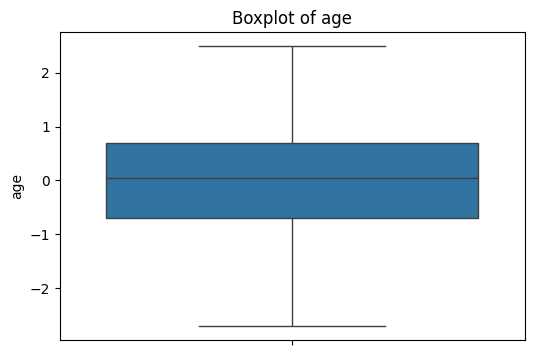

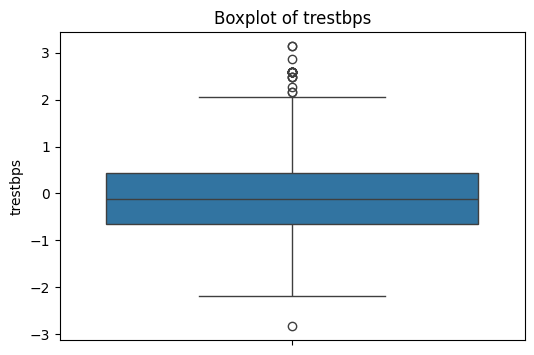

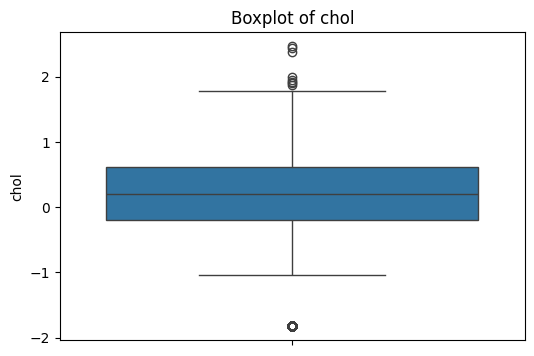

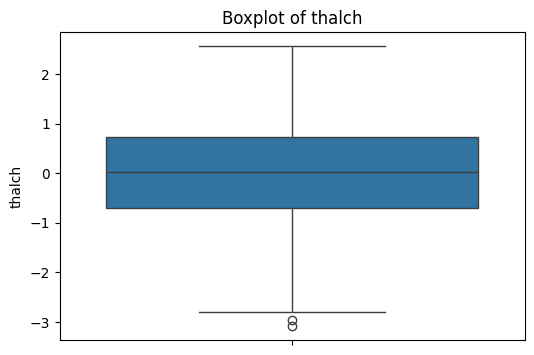

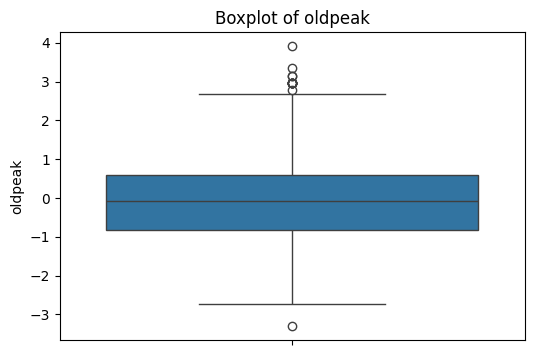

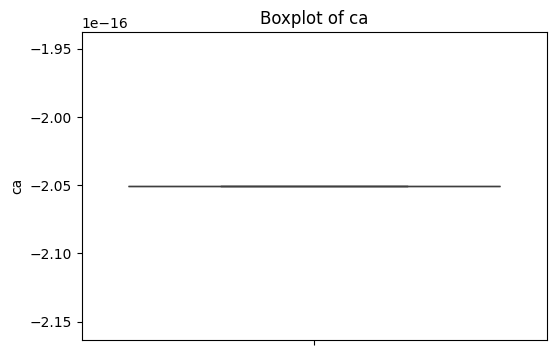

In [21]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()